<a href="https://colab.research.google.com/github/gallegoshernandezcarlosmihael01/MAA_Practicas_3_4_5/blob/main/Practica3_MAA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica 3 Regreseión Lineal Simple**

Gallegos Hernández Carlos Mihael , López Castillejos Aseret Laxhidua

# **Paso 1. Importar las bibliotecas**

In [95]:
# Importar NumPy para realizar operaciones numéricas.
import numpy as np


In [96]:
# Importar Pandas para organizar y analizar los datos.
import pandas as pd


In [97]:
# Importar Matplotlib para construir gráficas.
import matplotlib.pyplot as plt

In [98]:
# Importar la función para cargar el conjunto de datos.
from sklearn.datasets import fetch_california_housing

In [99]:
# Importar la función para dividir los datos.
from sklearn.model_selection import train_test_split

In [100]:
# Importar el algoritmo de regresión lineal.
from sklearn.linear_model import LinearRegression

In [101]:
# Importar métricas para evaluar las predicciones.
from sklearn.metrics import (
 mean_absolute_error,
 mean_squared_error,
 r2_score
)


# **Paso 2. Obtener los datos de California Housing**

In [102]:
# Cargar el conjunto de datos desde Scikit-learn.
# La primera descarga puede requerir conexión a internet.
datos = fetch_california_housing()


In [103]:
# Convertir las variables explicativas en un DataFrame.
X = pd.DataFrame(
 datos.data,
 columns=datos.feature_names
)


In [104]:
# Crear una serie con la variable objetivo.
y = pd.Series(
 datos.target,
 name="MedHouseVal"
)

In [105]:
# Mostrar las primeras cinco filas de las variables de entrada.
print("Variables explicativas:")
display(X.head())

Variables explicativas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [107]:
# Mostrar los primeros cinco valores objetivo.
print("Variable objetivo:")
display(y.head())

Variable objetivo:


,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


# **Paso 3. Conocer las dimensiones y características del conjunto**

In [108]:
# Mostrar el número de filas y columnas de las variables de entrada.
print("Dimensiones de X:", X.shape)

Dimensiones de X: (20640, 8)


In [109]:
# Mostrar la cantidad de valores objetivo.
print("Cantidad de valores objetivo:", y.shape[0])

Cantidad de valores objetivo: 20640


In [110]:
# Mostrar los nombres de las variables.
print("Variables disponibles:")
print(X.columns.tolist())


Variables disponibles:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [111]:
# Obtener estadísticas descriptivas de cada variable.
display(X.describe())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [112]:
# Contar los valores faltantes en cada columna.
print("Valores faltantes por variable:")
print(X.isnull().sum())

Valores faltantes por variable:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


In [113]:
# Verificar si existen valores faltantes en la variable objetivo.
print("Valores faltantes en y:", y.isnull().sum())

Valores faltantes en y: 0


# **Paso 4. Visualizar la distribución de la variable objetivo**

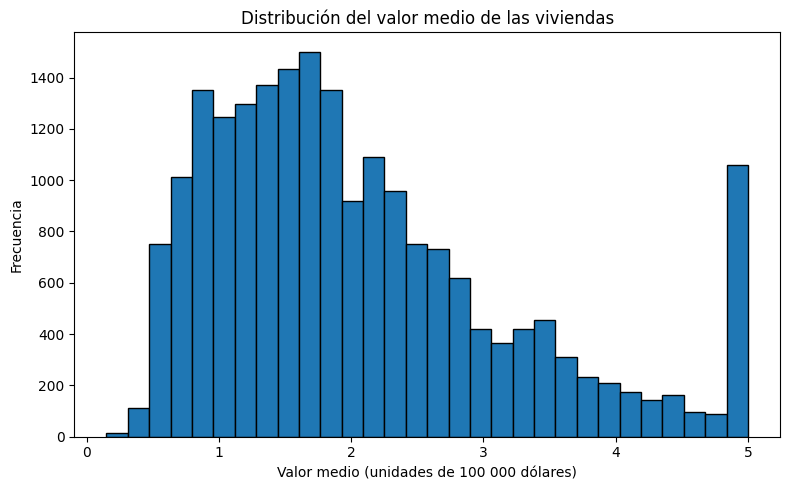

In [114]:
# Crear una figura para la distribución del valor de las viviendas.
plt.figure(figsize=(8, 5))
# Dibujar un histograma con 30 intervalos.
plt.hist(y, bins=30, edgecolor="black")
# Agregar el título de la gráfica.
plt.title("Distribución del valor medio de las viviendas")
# Identificar el eje horizontal.
plt.xlabel("Valor medio (unidades de 100 000 dólares)")
# Identificar el eje vertical.
plt.ylabel("Frecuencia")
# Ajustar los elementos para evitar superposiciones.
plt.tight_layout()
# Mostrar la gráfica.
plt.show()

# **Paso 5. Crear los conjuntos de entrenamiento y prueba**

In [115]:
# Dividir los datos en entrenamiento y prueba.
# El 80 % se utiliza para entrenar y el 20 % para evaluar.
X_train, X_test, y_train, y_test = train_test_split(
 X,
 y,
 test_size=0.20,
 random_state=42
)


In [116]:
# Mostrar el número de registros de entrenamiento.
print("Registros de entrenamiento:", X_train.shape[0])

Registros de entrenamiento: 16512


In [117]:
# Mostrar el número de registros de prueba.
print("Registros de prueba:", X_test.shape[0])


Registros de prueba: 4128


# **Paso 6. Crear y ajustar el modelo**

In [118]:
# Crear una instancia del modelo de regresión lineal.
modelo = LinearRegression()
# Ajustar el modelo utilizando los datos de entrenamiento.
# El algoritmo aprende los coeficientes de las ocho variables.
modelo.fit(X_train, y_train)
# Mostrar el intercepto aprendido por el modelo.
print("Intercepto:", modelo.intercept_)
# Mostrar los coeficientes de cada variable explicativa.
print("Coeficientes:")
# Asociar cada nombre de variable con su coeficiente.
for nombre, coeficiente in zip(
 X.columns,
 modelo.coef_
):
 # Imprimir el nombre y el coeficiente con cuatro decimales.
 print(f"{nombre}: {coeficiente:.4f}")

Intercepto: -37.02327770606409
Coeficientes:
MedInc: 0.4487
HouseAge: 0.0097
AveRooms: -0.1233
AveBedrms: 0.7831
Population: -0.0000
AveOccup: -0.0035
Latitude: -0.4198
Longitude: -0.4337


# **Paso 7. Estimar los valores del conjunto de prueba**

In [119]:
# Utilizar el modelo entrenado para predecir los valores de prueba.
y_pred = modelo.predict(X_test)

In [120]:
# Crear una tabla con los valores reales y las predicciones.
resultados = pd.DataFrame({
 "Valor real": y_test,
 "Valor predicho": y_pred
})


In [121]:
# Mostrar las primeras diez comparaciones.
display(resultados.head(10))

,Valor real,Valor predicho
20046,0.47700,0.719123
3024,0.45800,1.764017
15663,5.00001,2.709659
20484,2.18600,2.838926
9814,2.78000,2.604657
13311,1.58700,2.011754
7113,1.98200,2.645500
7668,1.57500,2.168755
18246,3.40000,2.740746
5723,4.46600,3.915615


# **Paso 8. Calcular las métricas de regresión**

In [122]:
# Calcular el error absoluto medio.
mae = mean_absolute_error(y_test, y_pred)

In [123]:
# Calcular la raíz del error cuadrático medio.
# squared=False solicita directamente la raíz del MSE.
# Si tu versión de Scikit-learn no admite este parámetro,
# utiliza np.sqrt(mean_squared_error(y_test, y_pred)).
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [124]:
# Calcular el coeficiente de determinación.
r2 = r2_score(y_test, y_pred)


In [126]:
# Mostrar las métricas obtenidas.
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")


MAE: 0.5332
RMSE: 0.7456
R²: 0.5758


# **Paso 9. Comparar los valores reales con los estimados**

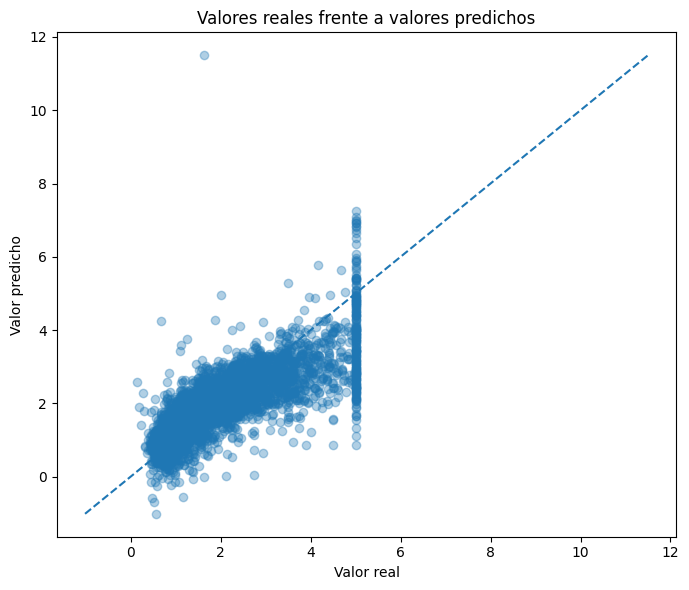

In [127]:
# Crear una figura para comparar los valores reales y predichos.
plt.figure(figsize=(7, 6))
# Graficar los valores reales en el eje horizontal
# y las predicciones en el eje vertical.
plt.scatter(y_test, y_pred, alpha=0.35)
# Calcular los límites comunes de ambos ejes.
limite_min = min(y_test.min(), y_pred.min())
limite_max = max(y_test.max(), y_pred.max())
# Dibujar una línea de referencia para predicciones perfectas.
plt.plot(
 [limite_min, limite_max],
 [limite_min, limite_max],
 linestyle="--"
)
# Agregar título y nombres de los ejes.
plt.title("Valores reales frente a valores predichos")
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
# Mostrar la gráfica.
plt.tight_layout()
plt.show()


# **Paso 10. Analizar los residuos**

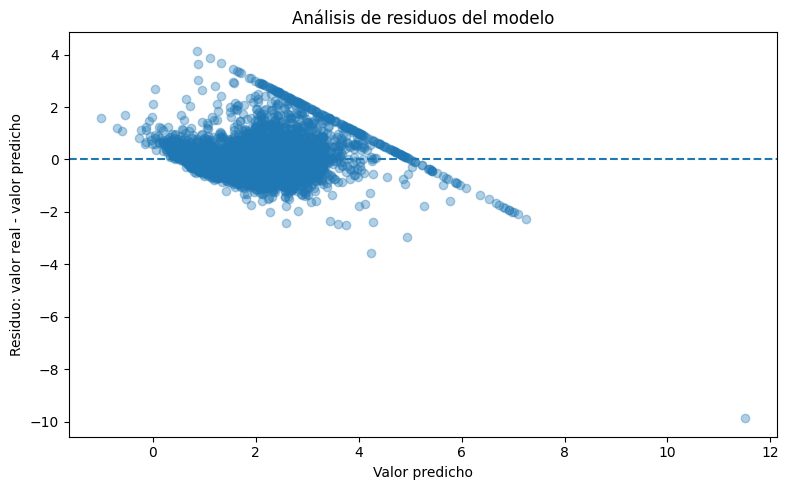

In [128]:
# Calcular los residuos del conjunto de prueba.
residuos = y_test - y_pred
# Crear la gráfica de residuos frente a predicciones.
plt.figure(figsize=(8, 5))
# Mostrar la relación entre predicciones y errores.
plt.scatter(y_pred, residuos, alpha=0.35)
# Dibujar la línea horizontal que representa error cero.
plt.axhline(y=0, linestyle="--")
# Agregar etiquetas y título.
plt.title("Análisis de residuos del modelo")
plt.xlabel("Valor predicho")
plt.ylabel("Residuo: valor real - valor predicho")
# Ajustar el diseño y mostrar la gráfica.
plt.tight_layout()
plt.show()


# **Paso 11. Entrenar el modelo simple y comparar métricas**

In [129]:
# Seleccionar únicamente la variable MedInc para el modelo simple.
X_simple = X[["MedInc"]]
# Dividir la variable simple usando la misma proporción y semilla.
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
X_simple,
y,
test_size=0.20,
random_state=42
)
# Crear el modelo de regresión lineal simple.
modelo_simple = LinearRegression()
# Entrenar el modelo con una sola variable.
modelo_simple.fit(X_train_s, y_train_s)
# Generar predicciones para el conjunto de prueba.
pred_simple = modelo_simple.predict(X_test_s)
# Calcular el MAE del modelo simple.
mae_simple = mean_absolute_error(y_test_s, pred_simple)
# Calcular el RMSE del modelo simple.
rmse_simple = np.sqrt(
mean_squared_error(y_test_s, pred_simple)
)
# Calcular el R² del modelo simple.
r2_simple = r2_score(y_test_s, pred_simple)
# Crear una tabla que compare ambos modelos.
comparacion = pd.DataFrame({
"Modelo": ["Regresión simple", "Regresión múltiple"],
"MAE": [mae_simple, mae],
"RMSE": [rmse_simple, rmse],
"R²": [r2_simple, r2]
})
# Mostrar los resultados para su análisis.
display(comparacion)

,Modelo,MAE,RMSE,R²
0,Regresión simple,0.629909,0.842090,0.458859
1,Regresión múltiple,0.533200,0.745581,0.575788


# **Actividad adicional: evaluación de un modelo de regresión múltiple con selección de variables.**

In [130]:
# Definir las cuatro variables seleccionadas para el reto.

variables_reto = [
"MedInc",
"HouseAge",
"Latitude",
"Longitude"
]
# Crear el conjunto de entrada con las variables seleccionadas.
X_reto = X[variables_reto]
# Dividir los datos conservando la misma semilla.
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
X_reto,
y,
test_size=0.20,
random_state=42
)
# Crear el modelo de regresión para el reto.
modelo_reto = LinearRegression()
# Ajustar el modelo con los datos de entrenamiento.
modelo_reto.fit(X_train_r, y_train_r)
# Predecir los valores del conjunto de prueba.
pred_reto = modelo_reto.predict(X_test_r)
# Calcular las métricas del modelo reducido.
mae_reto = mean_absolute_error(y_test_r, pred_reto)
rmse_reto = np.sqrt(
mean_squared_error(y_test_r, pred_reto)
)
r2_reto = r2_score(y_test_r, pred_reto)
# Mostrar los resultados del modelo reducido.
print(f"MAE del modelo reducido: {mae_reto:.4f}")
print(f"RMSE del modelo reducido: {rmse_reto:.4f}")
print(f"R² del modelo reducido: {r2_reto:.4f}")

MAE del modelo reducido: 0.5434
RMSE del modelo reducido: 0.7409
R² del modelo reducido: 0.5811
